In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
df = pd.read_csv("C:/Users/insan/OneDrive/Documents/archive (7)/Internship_Selection_Dataset.csv")

In [3]:
df.head()

,student_id,CGPA,skills_score,projects_count,internships_done,communication_score,aptitude_score,coding_test_score,resume_score,extracurricular,...,hackathons_participated,certifications_count,linkedin_activity_score,github_score,soft_skills_score,interview_score,consistency_score,backlogs,placement_training,selected
0,1,6.87,7,0,0,4,3,2,7,Yes,...,0,7,5,9,3,1,4,4,Yes,1
1,2,9.75,4,4,2,3,3,6,1,Yes,...,3,2,8,8,3,9,8,5,Yes,1
2,3,8.66,2,1,1,2,1,4,6,Yes,...,4,1,5,2,2,1,3,2,Yes,1
3,4,7.99,5,4,2,8,8,10,8,No,...,1,5,5,9,2,7,10,1,Yes,1
4,5,5.78,3,2,2,4,9,1,7,Yes,...,4,7,3,8,7,8,6,5,Yes,1


In [4]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())

Shape: (10000, 21)

Columns:
['student_id', 'CGPA', 'skills_score', 'projects_count', 'internships_done', 'communication_score', 'aptitude_score', 'coding_test_score', 'resume_score', 'extracurricular', 'college_tier', 'hackathons_participated', 'certifications_count', 'linkedin_activity_score', 'github_score', 'soft_skills_score', 'interview_score', 'consistency_score', 'backlogs', 'placement_training', 'selected']

Data types:
student_id                   int64
CGPA                       float64
skills_score                 int64
projects_count               int64
internships_done             int64
communication_score          int64
aptitude_score               int64
coding_test_score            int64
resume_score                 int64
extracurricular             object
college_tier                object
hackathons_participated      int64
certifications_count         int64
linkedin_activity_score      int64
github_score                 int64
soft_skills_score            int64
intervi

,student_id,CGPA,skills_score,projects_count,internships_done,communication_score,aptitude_score,coding_test_score,resume_score,extracurricular,...,hackathons_participated,certifications_count,linkedin_activity_score,github_score,soft_skills_score,interview_score,consistency_score,backlogs,placement_training,selected
0,1,6.87,7,0,0,4,3,2,7,Yes,...,0,7,5,9,3,1,4,4,Yes,1
1,2,9.75,4,4,2,3,3,6,1,Yes,...,3,2,8,8,3,9,8,5,Yes,1
2,3,8.66,2,1,1,2,1,4,6,Yes,...,4,1,5,2,2,1,3,2,Yes,1
3,4,7.99,5,4,2,8,8,10,8,No,...,1,5,5,9,2,7,10,1,Yes,1
4,5,5.78,3,2,2,4,9,1,7,Yes,...,4,7,3,8,7,8,6,5,Yes,1


In [5]:
print(df.columns.tolist())

['student_id', 'CGPA', 'skills_score', 'projects_count', 'internships_done', 'communication_score', 'aptitude_score', 'coding_test_score', 'resume_score', 'extracurricular', 'college_tier', 'hackathons_participated', 'certifications_count', 'linkedin_activity_score', 'github_score', 'soft_skills_score', 'interview_score', 'consistency_score', 'backlogs', 'placement_training', 'selected']


In [6]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe())

Dataset Shape: (10000, 21)

Column Names:
['student_id', 'CGPA', 'skills_score', 'projects_count', 'internships_done', 'communication_score', 'aptitude_score', 'coding_test_score', 'resume_score', 'extracurricular', 'college_tier', 'hackathons_participated', 'certifications_count', 'linkedin_activity_score', 'github_score', 'soft_skills_score', 'interview_score', 'consistency_score', 'backlogs', 'placement_training', 'selected']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   student_id               10000 non-null  int64  
 1   CGPA                     10000 non-null  float64
 2   skills_score             10000 non-null  int64  
 3   projects_count           10000 non-null  int64  
 4   internships_done         10000 non-null  int64  
 5   communication_score      10000 non-null  int64  
 6   

,student_id,CGPA,skills_score,projects_count,internships_done,communication_score,aptitude_score,coding_test_score,resume_score,hackathons_participated,certifications_count,linkedin_activity_score,github_score,soft_skills_score,interview_score,consistency_score,backlogs,selected
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.0000,10000.00000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000
mean,5000.50000,7.470792,5.480200,2.534300,1.502000,5.562800,5.526600,5.44940,5.572200,2.520500,4.474100,5.5000,5.49650,5.480200,5.469400,5.49130,2.502100,0.737400
std,2886.89568,1.438135,2.884829,1.690713,1.115043,2.864765,2.861627,2.86532,2.875868,1.699079,2.871124,2.8876,2.88094,2.881708,2.864557,2.88145,1.711341,0.440069
min,1.00000,5.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.00000,1.000000,0.000000,0.000000,1.0000,1.00000,1.000000,1.000000,1.00000,0.000000,0.000000
25%,2500.75000,6.230000,3.000000,1.000000,1.000000,3.000000,3.000000,3.00000,3.000000,1.000000,2.000000,3.0000,3.00000,3.000000,3.000000,3.00000,1.000000,0.000000
50%,5000.50000,7.460000,5.000000,3.000000,2.000000,6.000000,6.000000,5.00000,6.000000,3.000000,4.000000,6.0000,6.00000,5.000000,5.000000,5.00000,3.000000,1.000000
75%,7500.25000,8.700000,8.000000,4.000000,2.000000,8.000000,8.000000,8.00000,8.000000,4.000000,7.000000,8.0000,8.00000,8.000000,8.000000,8.00000,4.000000,1.000000
max,10000.00000,10.000000,10.000000,5.000000,3.000000,10.000000,10.000000,10.00000,10.000000,5.000000,9.000000,10.0000,10.00000,10.000000,10.000000,10.00000,5.000000,1.000000


In [7]:
missing_values = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

display(missing_values)

,Missing Values,Percentage
student_id,0,0.0
CGPA,0,0.0
skills_score,0,0.0
projects_count,0,0.0
internships_done,0,0.0
communication_score,0,0.0
aptitude_score,0,0.0
coding_test_score,0,0.0
resume_score,0,0.0
extracurricular,0,0.0


In [8]:
print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)

Duplicate rows: 0
Shape after removing duplicates: (10000, 21)


In [9]:
target = "selected"

print("Selection Counts:")
print(df[target].value_counts())

print("\nSelection Percentage:")
print(df[target].value_counts(normalize=True) * 100)

Selection Counts:
selected
1    7374
0    2626
Name: count, dtype: int64

Selection Percentage:
selected
1    73.74
0    26.26
Name: proportion, dtype: float64


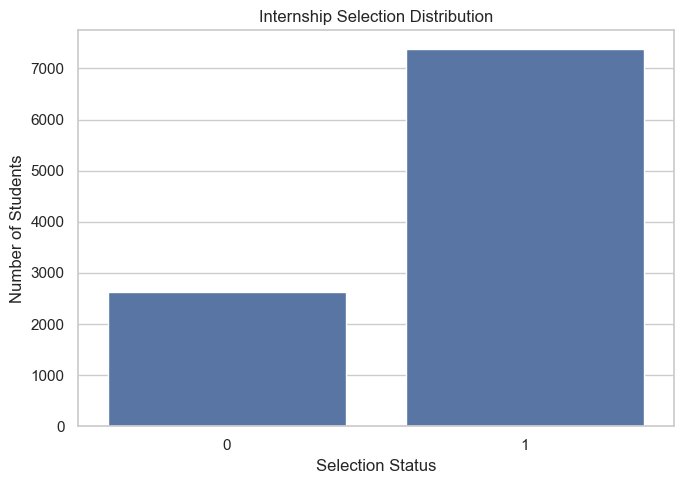

In [10]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x=target)

plt.title("Internship Selection Distribution")
plt.xlabel("Selection Status")
plt.ylabel("Number of Students")

plt.tight_layout()
plt.show()

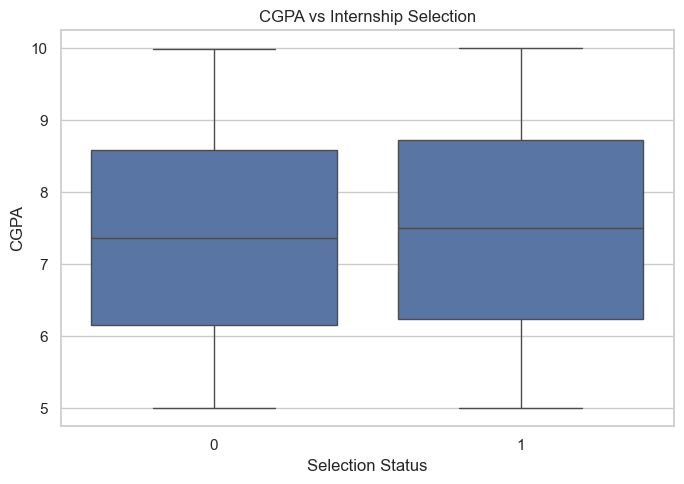

In [11]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x=target,
    y="CGPA"
)

plt.title("CGPA vs Internship Selection")
plt.xlabel("Selection Status")
plt.ylabel("CGPA")

plt.tight_layout()
plt.show()

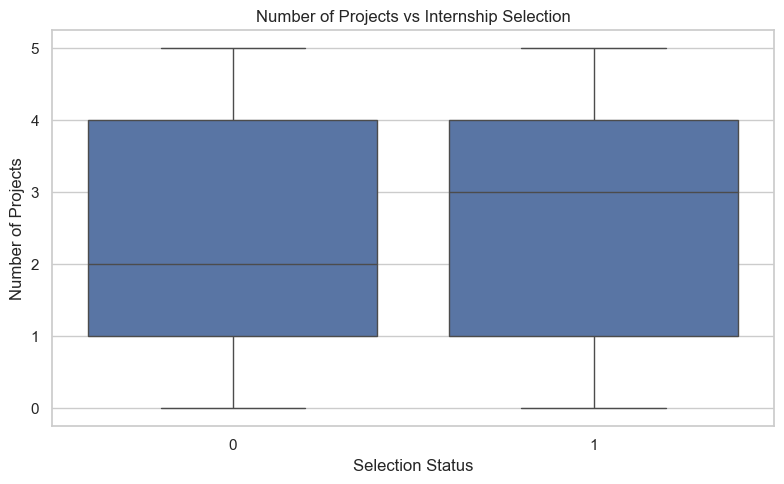

In [12]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x=target,
    y="projects_count"
)

plt.title("Number of Projects vs Internship Selection")
plt.xlabel("Selection Status")
plt.ylabel("Number of Projects")

plt.tight_layout()
plt.show()

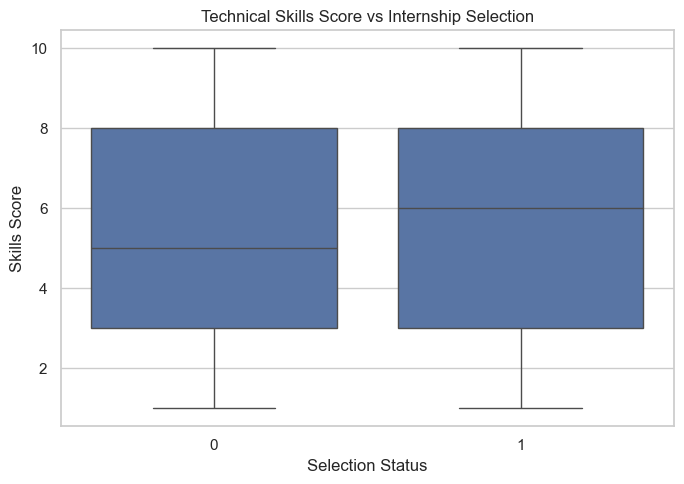

In [13]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x=target,
    y="skills_score"
)

plt.title("Technical Skills Score vs Internship Selection")
plt.xlabel("Selection Status")
plt.ylabel("Skills Score")

plt.tight_layout()
plt.show()

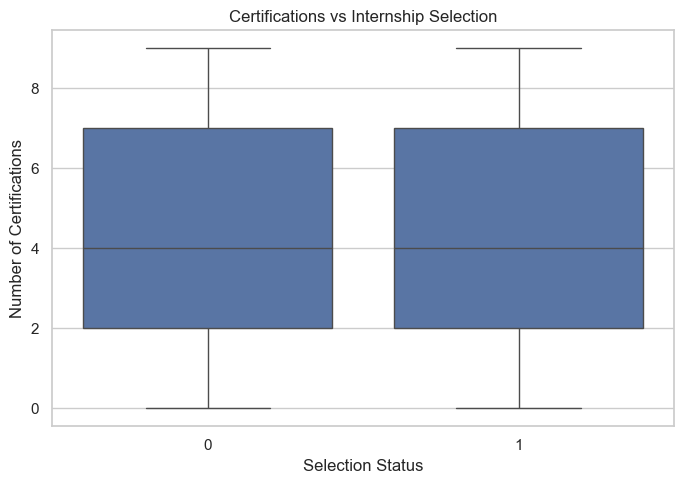

In [14]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x=target,
    y="certifications_count"
)

plt.title("Certifications vs Internship Selection")
plt.xlabel("Selection Status")
plt.ylabel("Number of Certifications")

plt.tight_layout()
plt.show()

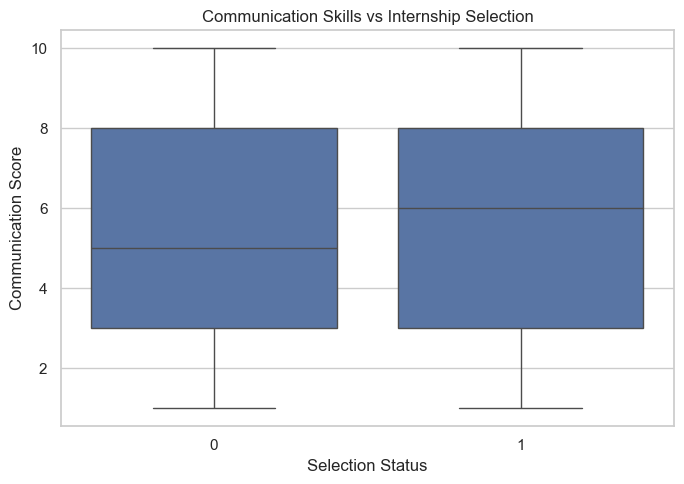

In [15]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x=target,
    y="communication_score"
)

plt.title("Communication Skills vs Internship Selection")
plt.xlabel("Selection Status")
plt.ylabel("Communication Score")

plt.tight_layout()
plt.show()

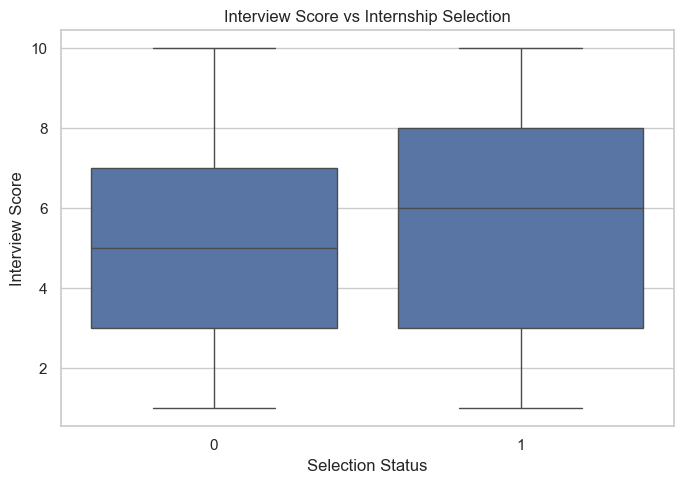

In [16]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x=target,
    y="interview_score"
)

plt.title("Interview Score vs Internship Selection")
plt.xlabel("Selection Status")
plt.ylabel("Interview Score")

plt.tight_layout()
plt.show()

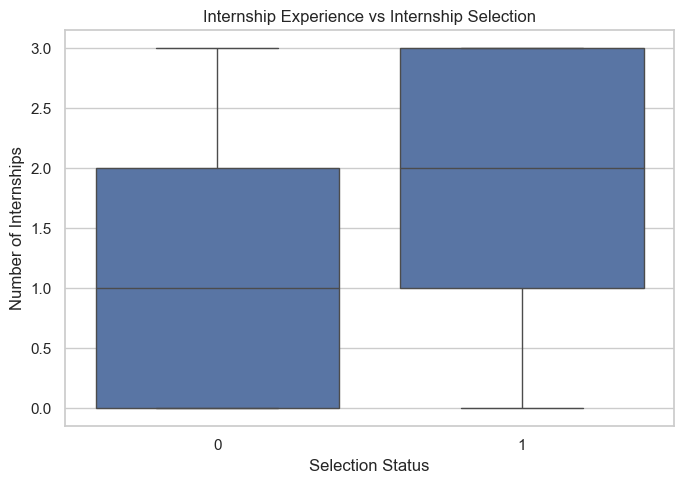

In [17]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x=target,
    y="internships_done"
)

plt.title("Internship Experience vs Internship Selection")
plt.xlabel("Selection Status")
plt.ylabel("Number of Internships")

plt.tight_layout()
plt.show()

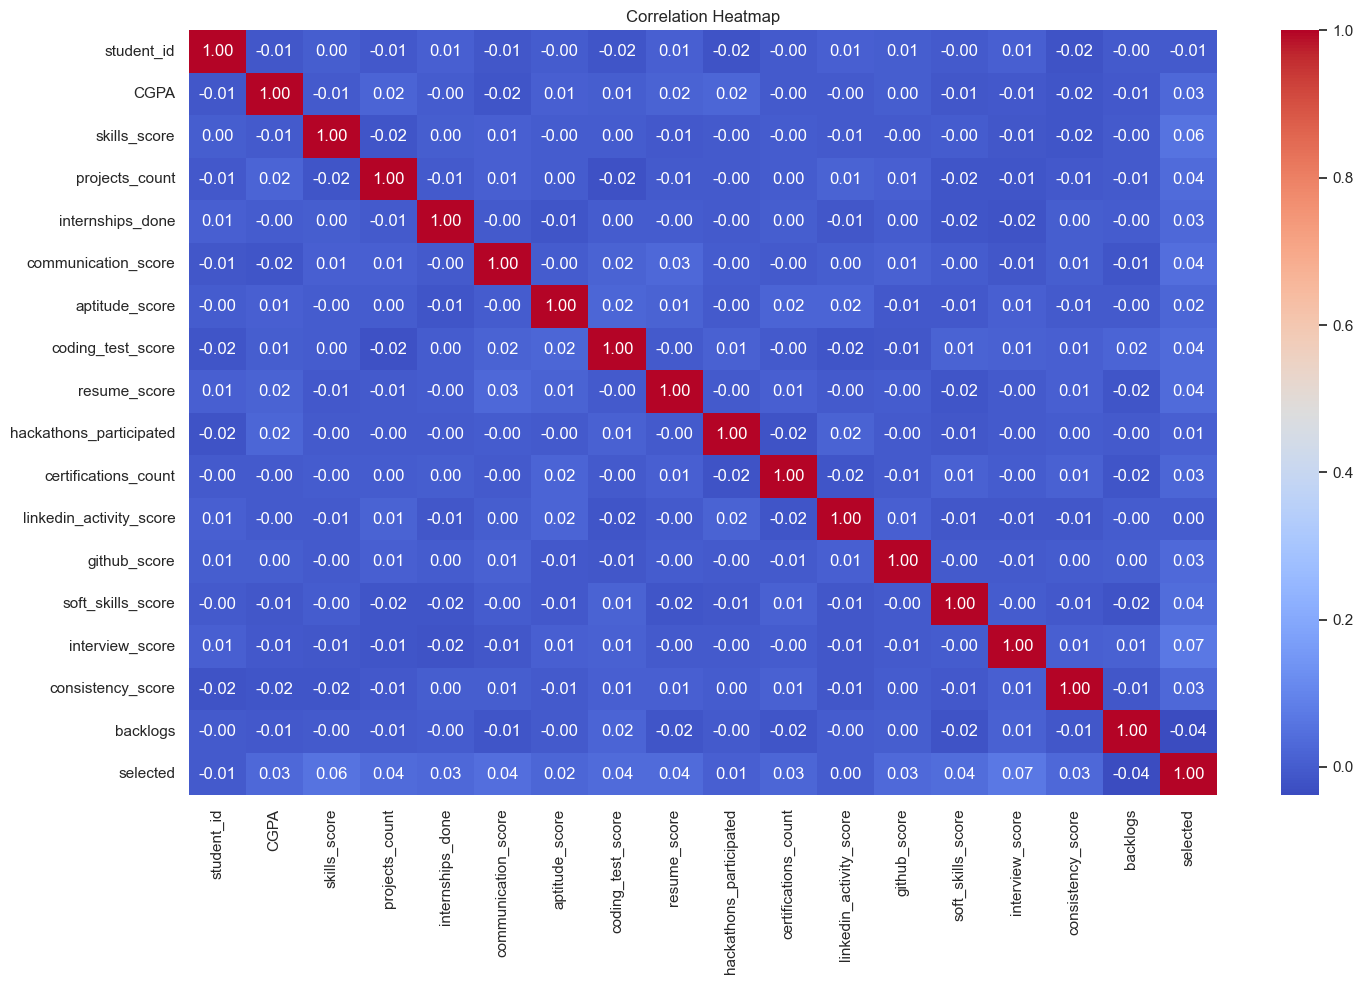

In [18]:
plt.figure(figsize=(15, 10))

numeric_columns = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_columns.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [19]:
X = df.drop(columns=["selected", "student_id"])
y = df["selected"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.head())

Features:
['CGPA', 'skills_score', 'projects_count', 'internships_done', 'communication_score', 'aptitude_score', 'coding_test_score', 'resume_score', 'extracurricular', 'college_tier', 'hackathons_participated', 'certifications_count', 'linkedin_activity_score', 'github_score', 'soft_skills_score', 'interview_score', 'consistency_score', 'backlogs', 'placement_training']

Target:
0    1
1    1
2    1
3    1
4    1
Name: selected, dtype: int64


In [20]:
categorical_columns = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

numerical_columns = X.select_dtypes(
    include=np.number
).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

print("\nNumerical columns:")
print(numerical_columns)

Categorical columns:
['extracurricular', 'college_tier', 'placement_training']

Numerical columns:
['CGPA', 'skills_score', 'projects_count', 'internships_done', 'communication_score', 'aptitude_score', 'coding_test_score', 'resume_score', 'hackathons_participated', 'certifications_count', 'linkedin_activity_score', 'github_score', 'soft_skills_score', 'interview_score', 'consistency_score', 'backlogs']


In [21]:
label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y.astype(str))

print("Target classes:")
print(label_encoder.classes_)

Target classes:
['0' '1']


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 8000
Testing samples: 2000


In [23]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numerical_columns),
    ("cat", categorical_transformer, categorical_columns)
])

In [24]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        criterion="gini",
        max_depth=5,
        random_state=42
    ))
])

model.fit(X_train, y_train)

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


In [25]:
y_pred = model.predict(X_test)

print("Predictions completed.")

Predictions completed.


In [26]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("Model Performance")
print("---------------------------")
print(f"Accuracy :  {accuracy:.4f}")
print(f"Precision:  {precision:.4f}")
print(f"Recall   :  {recall:.4f}")
print(f"F1 Score :  {f1:.4f}")

Model Performance
---------------------------
Accuracy :  0.7315
Precision:  0.7378
Recall   :  0.9864
F1 Score :  0.8442


In [27]:
print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_,
    zero_division=0
))

              precision    recall  f1-score   support

           0       0.29      0.02      0.03       525
           1       0.74      0.99      0.84      1475

    accuracy                           0.73      2000
   macro avg       0.51      0.50      0.44      2000
weighted avg       0.62      0.73      0.63      2000



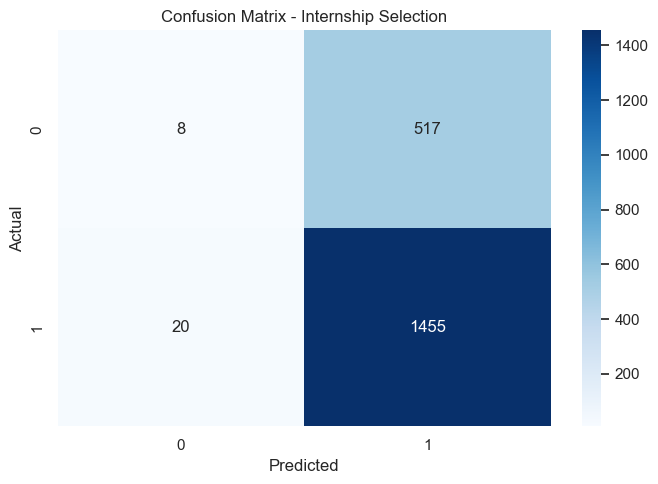

Confusion Matrix:
[[   8  517]
 [  20 1455]]


In [28]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix - Internship Selection")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

print("Confusion Matrix:")
print(cm)

In [29]:
tree_model = model.named_steps["classifier"]
preprocessor_model = model.named_steps["preprocessor"]

feature_names = preprocessor_model.get_feature_names_out()

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": tree_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

display(feature_importance.head(15))

,Feature,Importance
0,num__interview_score,0.170582
1,num__skills_score,0.106172
2,num__communication_score,0.087398
3,num__certifications_count,0.071449
4,num__backlogs,0.070856
5,num__coding_test_score,0.070835
6,num__consistency_score,0.067151
7,num__soft_skills_score,0.060472
8,num__CGPA,0.049673
9,num__projects_count,0.046914


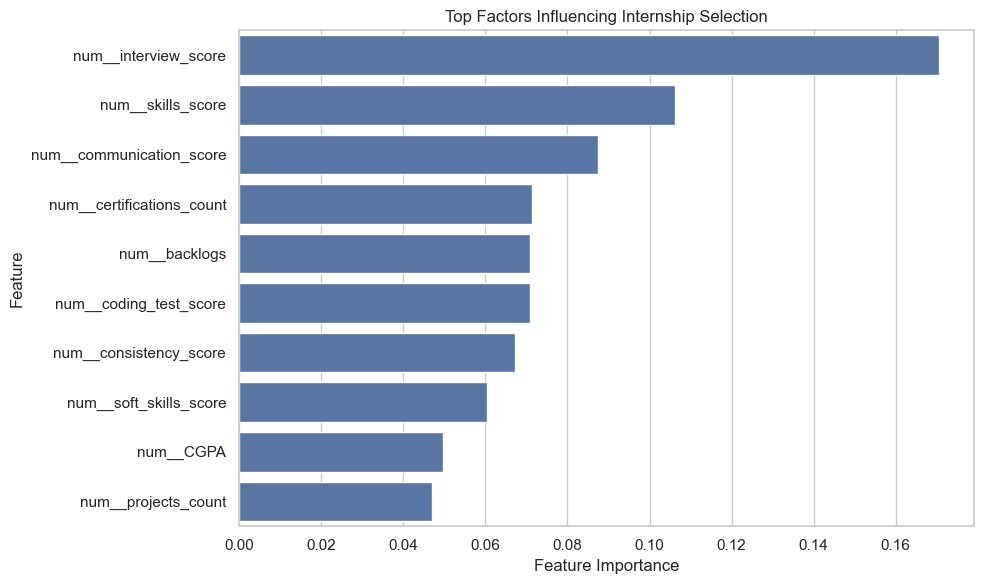

In [30]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top Factors Influencing Internship Selection")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [31]:
print("=" * 50)
print("INTERNSHIP SELECTION PREDICTION")
print("=" * 50)

print(f"Dataset size : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Accuracy     : {accuracy:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"F1 Score     : {f1:.4f}")

print("\nTop 5 Factors:")
display(feature_importance.head(5))

INTERNSHIP SELECTION PREDICTION
Dataset size : 10000 rows × 21 columns
Accuracy     : 0.7315
Precision    : 0.7378
Recall       : 0.9864
F1 Score     : 0.8442

Top 5 Factors:


,Feature,Importance
0,num__interview_score,0.170582
1,num__skills_score,0.106172
2,num__communication_score,0.087398
3,num__certifications_count,0.071449
4,num__backlogs,0.070856
